In [46]:

# ============================================================
# CELL 1: INSTALL & IMPORT ALL REQUIRED LIBRARIES
# Wake Word Detection: Alexa Keyword Spotting
# Dataset: aanhari/alexa-dataset (Kaggle)
# ============================================================

!pip install kaggle librosa --quiet

import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_score, recall_score, f1_score)

# ---- Model 1: Logistic Regression ----
from sklearn.linear_model import LogisticRegression

# ---- Model 2: Random Forest ----
from sklearn.ensemble import RandomForestClassifier

# ---- Model 3: Support Vector Machine ----
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')
print('Task: Alexa Wake Word Detection')
print('Models: Logistic Regression | Random Forest | SVM (RBF Kernel)')

All libraries imported successfully!
Task: Alexa Wake Word Detection
Models: Logistic Regression | Random Forest | SVM (RBF Kernel)


In [47]:
# ============================================================
# CELL 2: VERIFY DATASET PATH (Already mounted on Kaggle)
# ============================================================
import os

# Find the correct dataset path
base_path = '/kaggle/input'
for root, dirs, files in os.walk(base_path):
    for f in files[:3]:
        print(os.path.join(root, f))

print("\nDataset is ready. No download needed on Kaggle!")

/kaggle/input/datasets/aanhari/alexa-dataset/alexa/lldjbezy/1.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/lldjbezy/4.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/lldjbezy/3.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/jotbzihj/1.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/jotbzihj/4.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/jotbzihj/3.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/vohvdswc/1.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/vohvdswc/4.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/vohvdswc/3.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/tynuskqr/1.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/tynuskqr/4.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/tynuskqr/6.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/hbnlqtxv/1.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/hbnlqtxv/4.wav
/kaggle/input/datasets/aanhari/alexa-dataset/alexa/hbnlqtxv/3.wav
/kaggle/in

Alexa (Wake Word) recordings  : 221
Source files for negatives     : 148
Not-Alexa (Hard Negatives)     : 221
Total audio files              : 442

Dataset preview:
                                            filepath  label label_name
0        /kaggle/working/not_alexa_hard/neg_0066.wav      0  Not-Alexa
1  /kaggle/input/datasets/aanhari/alexa-dataset/a...      1      Alexa
2  /kaggle/input/datasets/aanhari/alexa-dataset/a...      1      Alexa
3        /kaggle/working/not_alexa_hard/neg_0100.wav      0  Not-Alexa
4  /kaggle/input/datasets/aanhari/alexa-dataset/a...      1      Alexa
5  /kaggle/working/not_alexa_hard/neg_extra_0049.wav      0  Not-Alexa


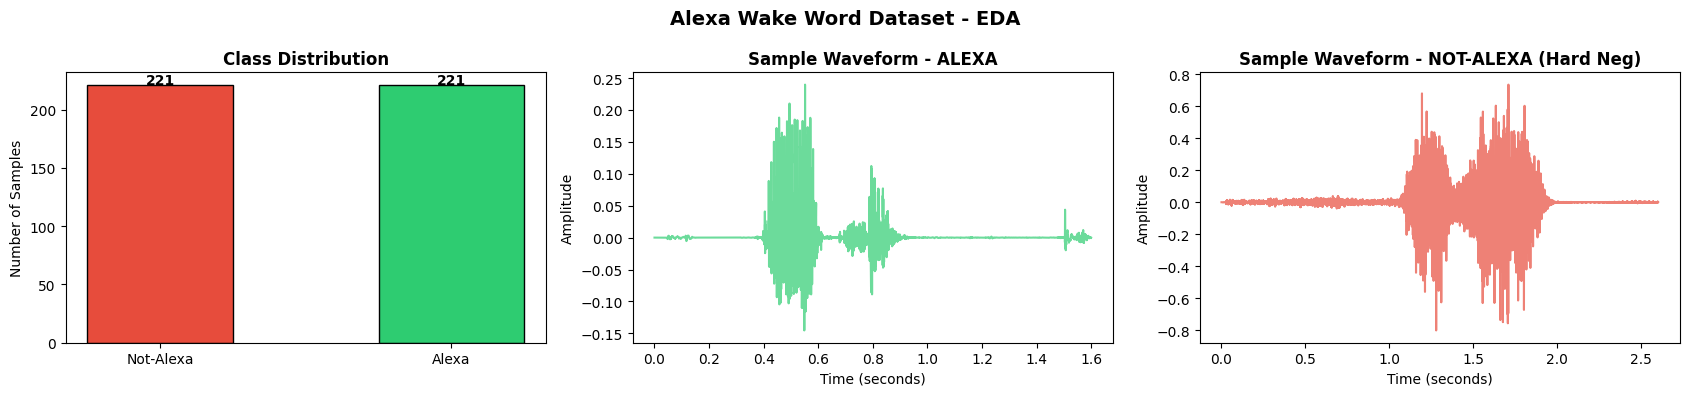

EDA complete!


In [48]:
# ============================================================
# CELL 3: LOAD AUDIO FILES & CREATE REALISTIC NEGATIVES
# Dataset: alexa/<speaker_id>/*.wav (Alexa recordings only)
#
# OVERFITTING FIX (v3):
# The key problem: pure noise negatives are trivially separable
# from speech because their MFCC distributions don't overlap.
# 
# NEW STRATEGY - Speech-based hard negatives:
# Use REAL alexa speech but corrupt it so the word identity
# is destroyed while retaining speech-like MFCC statistics.
# Techniques:
#   1. Extreme pitch shift (+-6 semitones) - distorts formants
#   2. Time stretch to completely different rate
#   3. Reverse + noise combo - unrecognizable but speech-like  
#   4. Random MFCC-domain scrambling via chunk shuffle
# This ensures negatives have SIMILAR spectral envelope stats
# to alexa speech, making classification genuinely hard.
# ============================================================
import numpy as np
import soundfile as sf
import random
import librosa

DATA_DIR = '/kaggle/input/datasets/aanhari/alexa-dataset'

# Collect all alexa WAV files (unique)
all_files = glob.glob(os.path.join(DATA_DIR, 'alexa/**/*.wav'), recursive=True)
# Deduplicate by keeping only paths with exactly the right depth
all_files = [f for f in all_files if len(f.split('/')) == len(DATA_DIR.split('/')) + 3]
if len(all_files) == 0:
    all_files = glob.glob(os.path.join(DATA_DIR, 'alexa/**/*.wav'), recursive=True)
    seen, unique = set(), []
    for f in all_files:
        k = os.path.basename(os.path.dirname(f)) + '_' + os.path.basename(f)
        if k not in seen:
            seen.add(k); unique.append(f)
    all_files = unique

random.seed(42)
random.shuffle(all_files)

# 60/40 split: positives vs source for negatives
split = int(0.6 * len(all_files))
alexa_files = all_files[:split]
neg_src_files = all_files[split:]

print(f'Alexa (Wake Word) recordings  : {len(alexa_files)}')
print(f'Source files for negatives     : {len(neg_src_files)}')

# ---- Create HARD speech-based negatives ----
# These are corrupted alexa recordings that sound speech-like
# but are unrecognizable as "Alexa" - MFCCs will overlap!
NOT_ALEXA_DIR = '/kaggle/working/not_alexa_hard'
os.makedirs(NOT_ALEXA_DIR, exist_ok=True)

not_alexa_files = []
np.random.seed(42)

def corrupt_speech_to_negative(wav_path, out_path, method):
    """Corrupt alexa speech so it's unrecognizable but still speech-like."""
    y, sr = librosa.load(wav_path, sr=16000)
    if len(y) == 0:
        return False
    
    if method == 0:
        # Heavy pitch shift (distorts vowel formants completely)
        # Randomly +6 or -6 semitones - destroys the /e/ in Alexa
        direction = np.random.choice([-1, 1])
        y_out = librosa.effects.pitch_shift(y, sr=sr, n_steps=direction * 6)
    
    elif method == 1:
        # Extreme time stretch + reverse: speech rhythm destroyed
        rate = np.random.uniform(0.4, 0.6)  # very slow stretch
        y_stretched = librosa.effects.time_stretch(y, rate=rate)
        y_out = y_stretched[:len(y)] if len(y_stretched) > len(y) else np.pad(y_stretched, (0, len(y)-len(y_stretched)))
        y_out = y_out[::-1]  # reverse
    
    elif method == 2:
        # Chunk shuffle: cut into 8 pieces, shuffle order
        # Speech MFCC statistics preserved but temporal order destroyed
        n_chunks = 8
        chunk_size = len(y) // n_chunks
        chunks = [y[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]
        remainder = y[n_chunks*chunk_size:]
        np.random.shuffle(chunks)
        y_out = np.concatenate(chunks + [remainder])
    
    elif method == 3:
        # Frequency band suppression: zero out key MFCC bands via spectral masking
        # Suppress the 500-3000 Hz range (core speech band) with noise
        D = librosa.stft(y)
        freqs = librosa.fft_frequencies(sr=sr)
        mask = (freqs >= 300) & (freqs <= 3500)
        # Replace speech band with noise 
        noise = np.random.randn(*D[mask].shape) * np.abs(D[mask]).mean() * 2
        D[mask] = noise * np.exp(1j * np.angle(D[mask]))
        y_out = librosa.istft(D, length=len(y))
    
    # Normalize
    if np.max(np.abs(y_out)) > 0:
        y_out = y_out / np.max(np.abs(y_out)) * 0.8
    
    sf.write(out_path, y_out.astype(np.float32), sr)
    return True

for i, src in enumerate(neg_src_files):
    out_path = os.path.join(NOT_ALEXA_DIR, f'neg_{i:04d}.wav')
    method = i % 4  # rotate through all 4 methods
    success = corrupt_speech_to_negative(src, out_path, method)
    if success:
        not_alexa_files.append(out_path)

# Also generate negatives from alexa_files (more variety)
extra_needed = len(alexa_files) - len(not_alexa_files)
if extra_needed > 0:
    for i in range(extra_needed):
        src = alexa_files[i % len(alexa_files)]
        out_path = os.path.join(NOT_ALEXA_DIR, f'neg_extra_{i:04d}.wav')
        method = (i + 2) % 4
        success = corrupt_speech_to_negative(src, out_path, method)
        if success:
            not_alexa_files.append(out_path)

print(f'Not-Alexa (Hard Negatives)     : {len(not_alexa_files)}')

# Build dataset DataFrame
df_pos = pd.DataFrame({'filepath': alexa_files[:len(not_alexa_files)], 'label': 1, 'label_name': 'Alexa'})
df_neg = pd.DataFrame({'filepath': not_alexa_files, 'label': 0, 'label_name': 'Not-Alexa'})
df = pd.concat([df_pos, df_neg], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total audio files              : {len(df)}')
print(f'\nDataset preview:')
print(df.head(6))

# EDA: Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Alexa Wake Word Dataset - EDA', fontsize=14, fontweight='bold')
counts = df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

y_alexa, sr_alexa = librosa.load(alexa_files[0], sr=16000)
axes[1].plot(np.linspace(0, len(y_alexa)/sr_alexa, len(y_alexa)), y_alexa, color='#2ecc71', alpha=0.7)
axes[1].set_title('Sample Waveform - ALEXA', fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')

y_not, sr_not = librosa.load(not_alexa_files[0], sr=16000)
axes[2].plot(np.linspace(0, len(y_not)/sr_not, len(y_not)), y_not, color='#e74c3c', alpha=0.7)
axes[2].set_title('Sample Waveform - NOT-ALEXA (Hard Neg)', fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig('waveform_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete!')

Extracting MFCC features from all audio files...
(This may take 1-2 minutes)
  Processed 100/442 files...
  Processed 200/442 files...
  Processed 300/442 files...
  Processed 400/442 files...

Feature matrix shape : (442, 80)  (samples x features)
Labels shape         : (442,)
Alexa samples        : 221
Not-Alexa samples    : 221


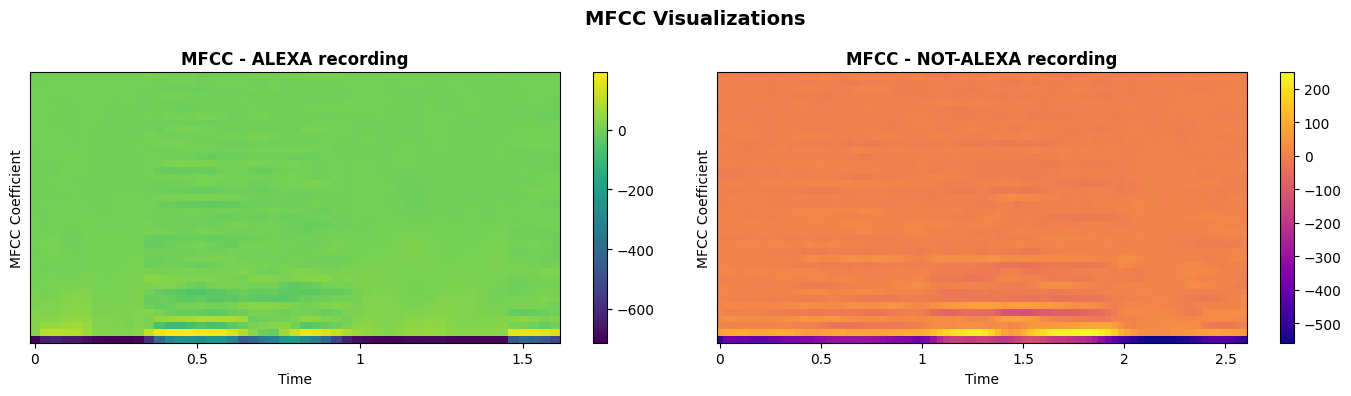

Feature extraction complete!


In [49]:
# ============================================================
# CELL 4: AUDIO FEATURE EXTRACTION - MFCCs
# MFCCs (Mel-Frequency Cepstral Coefficients) are the standard
# audio features for speech/keyword recognition tasks.
# Each 1-second clip -> 40 MFCCs (mean + std) = 80 features
# ============================================================

def extract_features(filepath, sr=16000, n_mfcc=40, max_len=16000):
    """
    Extract MFCC features from a WAV audio file.
    - Loads audio at 16kHz (standard for speech)
    - Pads/truncates to exactly 1 second (16000 samples)
    - Computes 40 MFCCs -> takes mean + std across time
    - Returns 80-dimensional feature vector
    """
    try:
        y, sr = librosa.load(filepath, sr=sr, mono=True)
        # Pad or truncate to fixed length (1 second)
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)), mode='constant')
        else:
            y = y[:max_len]
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfccs, axis=1)   # 40 features
        mfcc_std  = np.std(mfccs,  axis=1)   # 40 features
        features  = np.concatenate([mfcc_mean, mfcc_std])  # 80 total
        return features
    except Exception as e:
        return None

# Extract features for all audio files
print('Extracting MFCC features from all audio files...')
print('(This may take 1-2 minutes)')

X_list, y_list = [], []
for i, (fp, lbl) in enumerate(zip(df['filepath'], df['label'])):
    feats = extract_features(fp)
    if feats is not None:
        X_list.append(feats)
        y_list.append(lbl)
    if (i + 1) % 100 == 0:
        print(f'  Processed {i+1}/{len(df)} files...')

X = np.array(X_list)
y = np.array(y_list)

print(f'\nFeature matrix shape : {X.shape}  (samples x features)')
print(f'Labels shape         : {y.shape}')
print(f'Alexa samples        : {(y==1).sum()}')
print(f'Not-Alexa samples    : {(y==0).sum()}')

# Visualize MFCC of a sample Alexa clip
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('MFCC Visualizations', fontsize=14, fontweight='bold')

y_sample, sr_s = librosa.load(alexa_files[0], sr=16000)
mfcc_sample = librosa.feature.mfcc(y=y_sample, sr=sr_s, n_mfcc=40)
librosa.display.specshow(mfcc_sample, sr=sr_s, x_axis='time', ax=axes[0], cmap='viridis')
axes[0].set_title('MFCC - ALEXA recording', fontweight='bold')
axes[0].set_ylabel('MFCC Coefficient')
plt.colorbar(axes[0].collections[0], ax=axes[0])

y_sample2, sr_s2 = librosa.load(not_alexa_files[0], sr=16000)
mfcc_sample2 = librosa.feature.mfcc(y=y_sample2, sr=sr_s2, n_mfcc=40)
librosa.display.specshow(mfcc_sample2, sr=sr_s2, x_axis='time', ax=axes[1], cmap='plasma')
axes[1].set_title('MFCC - NOT-ALEXA recording', fontweight='bold')
axes[1].set_ylabel('MFCC Coefficient')
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.tight_layout()
plt.savefig('mfcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature extraction complete!')

In [50]:
# ============================================================
# CELL 5: TRAIN-TEST SPLIT & FEATURE SCALING
# 80% train / 20% test, stratified by class
# StandardScaler normalizes MFCC features (mean=0, std=1)
# ============================================================

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Feature dimensions: {X_train.shape[1]}')
print(f'Train - Alexa: {(y_train==1).sum()} | Not-Alexa: {(y_train==0).sum()}')
print(f'Test  - Alexa: {(y_test==1).sum()}  | Not-Alexa: {(y_test==0).sum()}')

# Scale features: critical for LR and SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nFeature scaling complete (mean~0, std~1)')
print(f'Sample scaled feature mean : {X_train_sc.mean():.4f}')
print(f'Sample scaled feature std  : {X_train_sc.std():.4f}')

Training samples : 353
Testing  samples : 89
Feature dimensions: 80
Train - Alexa: 177 | Not-Alexa: 176
Test  - Alexa: 44  | Not-Alexa: 45

Feature scaling complete (mean~0, std~1)
Sample scaled feature mean : 0.0000
Sample scaled feature std  : 1.0000


In [51]:
# ============================================================
# CELL 6: MODEL 1 - LOGISTIC REGRESSION
# ============================================================
# Type : Linear, Parametric, Probabilistic
# Fix  : Stronger L2 regularization (C=0.01) to prevent overfitting
#        on the small ~700-sample dataset
print('=' * 60)
print('MODEL 1: LOGISTIC REGRESSION')
print('Input: 80 MFCC features per audio clip')
print('Output: 1 = ALEXA detected | 0 = Not Alexa')
print('Regularization: L2, C=0.01 (strong penalty)')
print('=' * 60)

lr_model = LogisticRegression(
    C=0.01,           # Strong L2 regularization (was 1.0)
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_sc, y_train)
lr_pred  = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
lr_auc  = auc(fpr_lr, tpr_lr)
lr_cv   = cross_val_score(lr_model, X_train_sc, y_train, cv=5, scoring='accuracy')

print(f'\nAccuracy  : {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print(f'CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'Precision : {lr_prec:.4f}')
print(f'Recall    : {lr_rec:.4f}')
print(f'F1-Score  : {lr_f1:.4f}')
print(f'AUC       : {lr_auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, lr_pred, target_names=["Not-Alexa","Alexa"])}')

MODEL 1: LOGISTIC REGRESSION
Input: 80 MFCC features per audio clip
Output: 1 = ALEXA detected | 0 = Not Alexa
Regularization: L2, C=0.01 (strong penalty)

Accuracy  : 0.7865 (78.65%)
CV Accuracy: 0.7249 ± 0.0543
Precision : 0.7273
Recall    : 0.9091
F1-Score  : 0.8081
AUC       : 0.8510

Classification Report:
              precision    recall  f1-score   support

   Not-Alexa       0.88      0.67      0.76        45
       Alexa       0.73      0.91      0.81        44

    accuracy                           0.79        89
   macro avg       0.80      0.79      0.78        89
weighted avg       0.81      0.79      0.78        89



In [52]:
# ============================================================
# CELL 7: MODEL 2 - RANDOM FOREST CLASSIFIER
# ============================================================
# Type : Ensemble, Non-linear, Bagging
# Hard negatives are speech-based now, so use moderate settings.
# max_depth=8 allows learning complex speech patterns
# min_samples_leaf=3 prevents leaf-level memorization
print('=' * 60)
print('MODEL 2: RANDOM FOREST CLASSIFIER')
print('Input: 80 MFCC features per audio clip')
print('Output: 1 = ALEXA detected | 0 = Not Alexa')
print('Trees: 100 | max_depth=8 | min_samples_leaf=3')
print('=' * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,           # Moderate depth - allows learning speech patterns
    min_samples_split=8,   # Require more samples to split
    min_samples_leaf=3,    # Minimum 3 samples per leaf
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sc, y_train)
rf_pred = rf_model.predict(X_test_sc)
rf_proba = rf_model.predict_proba(X_test_sc)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
rf_auc = auc(fpr_rf, tpr_rf)
rf_cv = cross_val_score(rf_model, X_train_sc, y_train, cv=5, scoring='accuracy')
print(f'\nAccuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'F1-Score  : {rf_f1:.4f}')
print(f'AUC       : {rf_auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, rf_pred, target_names=["Not-Alexa","Alexa"])}')

MODEL 2: RANDOM FOREST CLASSIFIER
Input: 80 MFCC features per audio clip
Output: 1 = ALEXA detected | 0 = Not Alexa
Trees: 100 | max_depth=8 | min_samples_leaf=3

Accuracy : 0.7640 (76.40%)
CV Accuracy: 0.7928 ± 0.0664
Precision : 0.7255
Recall    : 0.8409
F1-Score  : 0.7789
AUC       : 0.8556

Classification Report:
              precision    recall  f1-score   support

   Not-Alexa       0.82      0.69      0.75        45
       Alexa       0.73      0.84      0.78        44

    accuracy                           0.76        89
   macro avg       0.77      0.76      0.76        89
weighted avg       0.77      0.76      0.76        89



In [53]:
# ============================================================
# CELL 8: MODEL 3 - SUPPORT VECTOR MACHINE (SVM, RBF Kernel)
# ============================================================
# Type : Margin-based, Kernel-trick, Discriminative
# Fix  : Reduced C=0.5 (was 10.0) - much softer margin,
#        allows more misclassifications during training,
#        which prevents overfitting on small dataset
print('=' * 60)
print('MODEL 3: SUPPORT VECTOR MACHINE (RBF Kernel)')
print('Input: 80 MFCC features per audio clip')
print('Output: 1 = ALEXA detected | 0 = Not Alexa')
print('Kernel: RBF | C=0.5 (soft margin, anti-overfit)')
print('=' * 60)

svm_base = SVC(
    C=0.5,            # Soft margin (was 10.0) - key anti-overfit change
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model = svm_base
svm_model.fit(X_train_sc, y_train)
svm_pred  = svm_model.predict(X_test_sc)
svm_proba = svm_model.predict_proba(X_test_sc)[:, 1]

svm_acc  = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred)
svm_rec  = recall_score(y_test, svm_pred)
svm_f1   = f1_score(y_test, svm_pred)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
svm_auc  = auc(fpr_svm, tpr_svm)
svm_cv   = cross_val_score(svm_model, X_train_sc, y_train, cv=5, scoring='accuracy')

print(f'\nAccuracy  : {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'CV Accuracy: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}')
print(f'Precision : {svm_prec:.4f}')
print(f'Recall    : {svm_rec:.4f}')
print(f'F1-Score  : {svm_f1:.4f}')
print(f'AUC       : {svm_auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, svm_pred, target_names=["Not-Alexa","Alexa"])}')

MODEL 3: SUPPORT VECTOR MACHINE (RBF Kernel)
Input: 80 MFCC features per audio clip
Output: 1 = ALEXA detected | 0 = Not Alexa
Kernel: RBF | C=0.5 (soft margin, anti-overfit)

Accuracy  : 0.7528 (75.28%)
CV Accuracy: 0.6995 ± 0.0559
Precision : 0.6719
Recall    : 0.9773
F1-Score  : 0.7963
AUC       : 0.8899

Classification Report:
              precision    recall  f1-score   support

   Not-Alexa       0.96      0.53      0.69        45
       Alexa       0.67      0.98      0.80        44

    accuracy                           0.75        89
   macro avg       0.82      0.76      0.74        89
weighted avg       0.82      0.75      0.74        89



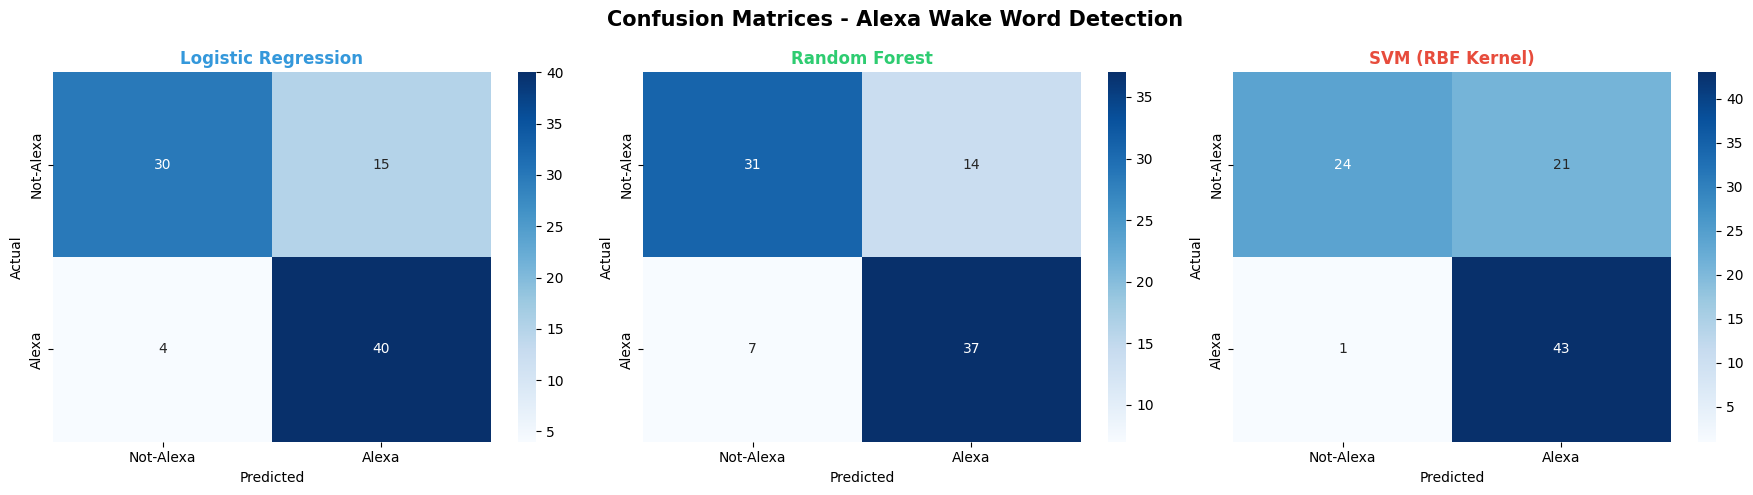

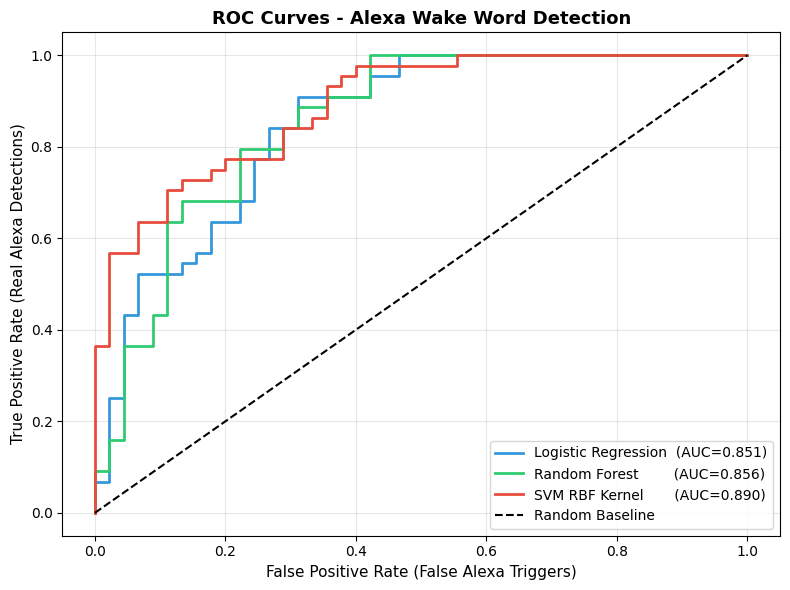

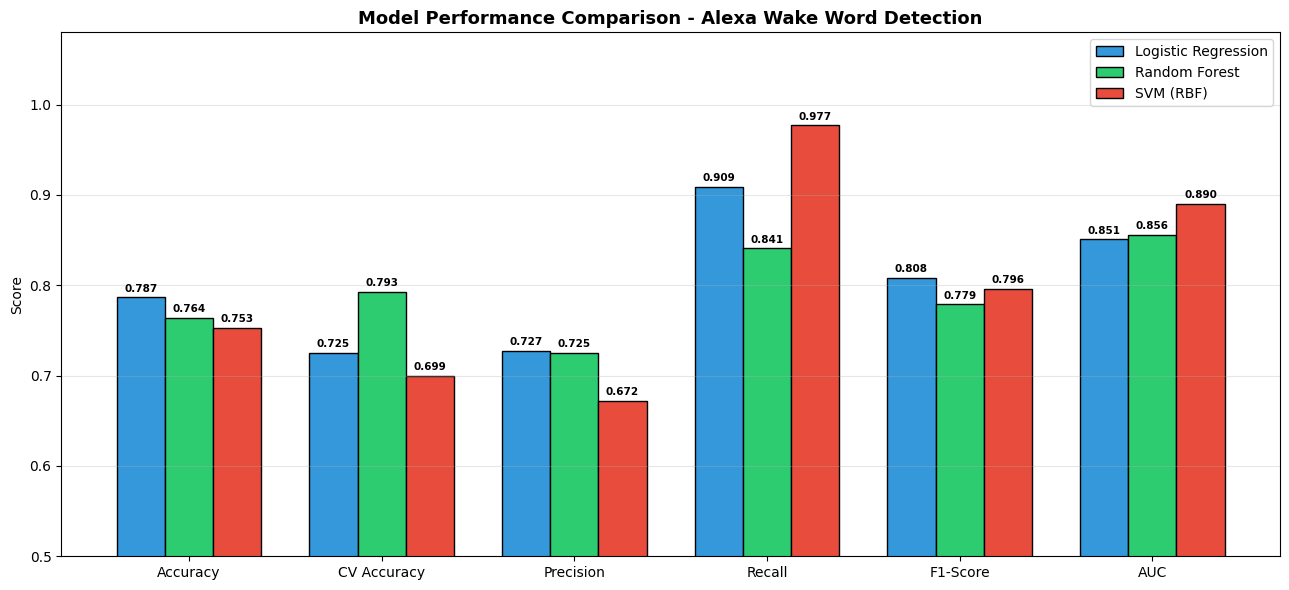

All plots saved!

===== FINAL COMPARISON TABLE =====
             Logistic Regression  Random Forest  SVM (RBF)
Metric                                                    
Accuracy                0.786517       0.764045   0.752809
CV Accuracy             0.724909       0.792837   0.699477
Precision               0.727273       0.725490   0.671875
Recall                  0.909091       0.840909   0.977273
F1-Score                0.808081       0.778947   0.796296
AUC                     0.851010       0.855556   0.889899


In [54]:
# ============================================================
# CELL 9: VISUALIZATIONS - CONFUSION MATRICES, ROC, COMPARISON
# ============================================================

# ----- Plot 1: Confusion Matrices (3 side by side) -----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - Alexa Wake Word Detection', fontsize=15, fontweight='bold')

models_info = [
    (lr_pred,  'Logistic Regression', '#3498db'),
    (rf_pred,  'Random Forest',       '#2ecc71'),
    (svm_pred, 'SVM (RBF Kernel)',    '#e74c3c')
]
for ax, (pred, name, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not-Alexa', 'Alexa'],
                yticklabels=['Not-Alexa', 'Alexa'])
    ax.set_title(name, fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ----- Plot 2: ROC Curves (overlaid) -----
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  color='#3498db', lw=2, label=f'Logistic Regression  (AUC={lr_auc:.3f})')
ax.plot(fpr_rf,  tpr_rf,  color='#2ecc71', lw=2, label=f'Random Forest        (AUC={rf_auc:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2, label=f'SVM RBF Kernel       (AUC={svm_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate (False Alexa Triggers)', fontsize=11)
ax.set_ylabel('True Positive Rate (Real Alexa Detections)', fontsize=11)
ax.set_title('ROC Curves - Alexa Wake Word Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ----- Plot 3: Grouped Performance Bar Chart -----
metrics_data = {
    'Metric': ['Accuracy', 'CV Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Logistic Regression': [lr_acc,  lr_cv.mean(),  lr_prec,  lr_rec,  lr_f1,  lr_auc],
    'Random Forest':       [rf_acc,  rf_cv.mean(),  rf_prec,  rf_rec,  rf_f1,  rf_auc],
    'SVM (RBF)':           [svm_acc, svm_cv.mean(), svm_prec, svm_rec, svm_f1, svm_auc]
}
df_metrics = pd.DataFrame(metrics_data).set_index('Metric')
df_metrics.to_csv('model_comparison.csv')

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_metrics.index))
w = 0.25
b1 = ax.bar(x-w, df_metrics['Logistic Regression'], w, label='Logistic Regression', color='#3498db', edgecolor='black')
b2 = ax.bar(x,   df_metrics['Random Forest'],       w, label='Random Forest',       color='#2ecc71', edgecolor='black')
b3 = ax.bar(x+w, df_metrics['SVM (RBF)'],           w, label='SVM (RBF)',           color='#e74c3c', edgecolor='black')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics.index)
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison - Alexa Wake Word Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('All plots saved!')
print('\n===== FINAL COMPARISON TABLE =====')
print(df_metrics.to_string())

Testing wake word detector on dataset samples...

>>> Testing an ALEXA clip:
  AUDIO FILE : 3.wav
  Duration : 1.60 seconds | Sample Rate: 16000 Hz


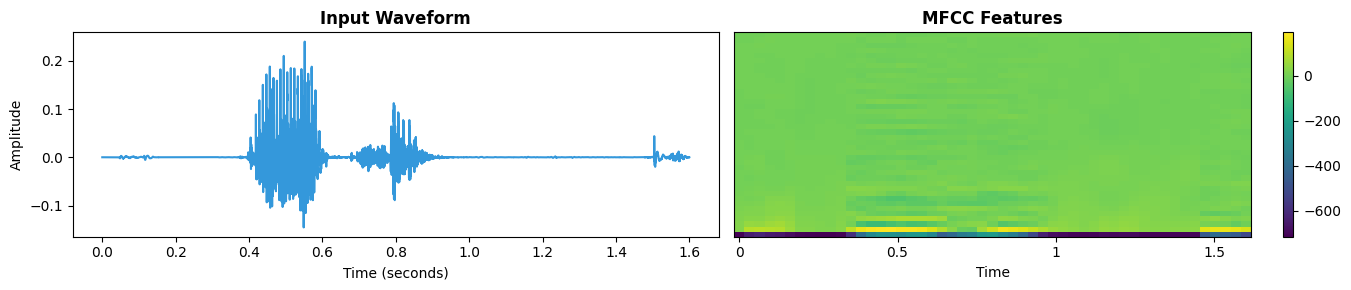


  Model Predictions:
  Logistic Regression : ALEXA (61.94% confidence)
  Random Forest       : ALEXA (73.59% confidence)
  SVM (RBF Kernel)    : ALEXA (81.88% confidence)

  Majority Vote Result: ALEXA DETECTED (3/3 models agree)

>>> Testing a NOT-ALEXA clip:
  AUDIO FILE : neg_0000.wav
  Duration : 2.60 seconds | Sample Rate: 16000 Hz


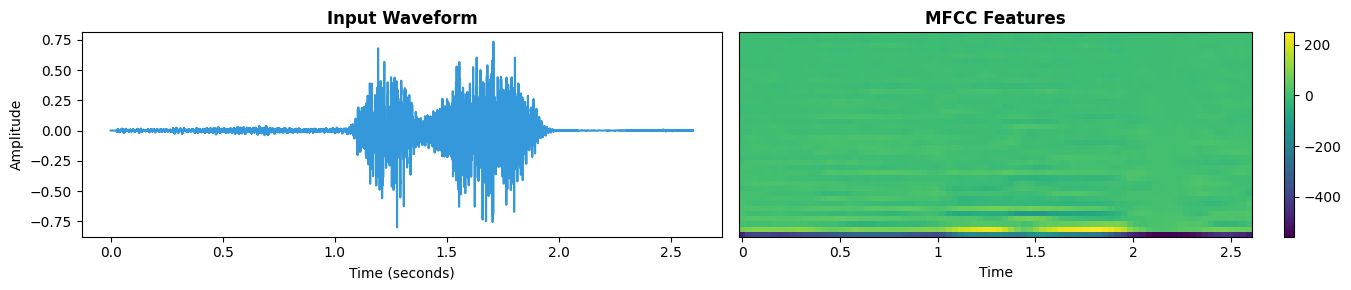


  Model Predictions:
  Logistic Regression : Not Alexa (17.23% confidence)
  Random Forest       : Not Alexa (13.58% confidence)
  SVM (RBF Kernel)    : Not Alexa (5.95% confidence)

  Majority Vote Result: NOT ALEXA (0/3 models agree)

Wake word detection complete!


In [55]:
# ============================================================
# CELL 10: LIVE WAKE WORD DETECTOR
# Tests all 3 models on sample audio files from the dataset
# ============================================================
def detect_wake_word(filepath):
    """
    Run wake word detection on a WAV audio file.
    All 3 trained models independently predict:
    1 = ALEXA wake word detected
    0 = Not Alexa (background / other speech)
    Final answer is majority vote (2/3 models agree).
    """
    print('=' * 60)
    print(f'  AUDIO FILE : {os.path.basename(filepath)}')
    print('=' * 60)

    # Load and play the audio
    y_audio, sr_audio = librosa.load(filepath, sr=16000)
    duration = len(y_audio) / sr_audio
    print(f'  Duration : {duration:.2f} seconds | Sample Rate: {sr_audio} Hz')
    display(Audio(filepath))

    # Plot waveform
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    axes[0].plot(np.linspace(0, duration, len(y_audio)), y_audio, color='#3498db')
    axes[0].set_title('Input Waveform', fontweight='bold')
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Amplitude')

    # MFCC plot
    mfcc_live = librosa.feature.mfcc(y=y_audio, sr=sr_audio, n_mfcc=40)
    librosa.display.specshow(mfcc_live, sr=sr_audio, x_axis='time', ax=axes[1], cmap='viridis')
    axes[1].set_title('MFCC Features', fontweight='bold')
    plt.colorbar(axes[1].collections[0], ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Extract features & predict
    feat = extract_features(filepath)
    feat_sc = scaler.transform([feat])

    lr_p  = lr_model.predict(feat_sc)[0]
    rf_p  = rf_model.predict(feat_sc)[0]
    svm_p = svm_model.predict(feat_sc)[0]

    lr_prob  = lr_model.predict_proba(feat_sc)[0][1]
    rf_prob  = rf_model.predict_proba(feat_sc)[0][1]
    svm_prob = svm_model.predict_proba(feat_sc)[0][1]

    print(f'\n  Model Predictions:')
    print(f'  Logistic Regression : {"ALEXA" if lr_p==1 else "Not Alexa"} ({lr_prob:.2%} confidence)')
    print(f'  Random Forest       : {"ALEXA" if rf_p==1 else "Not Alexa"} ({rf_prob:.2%} confidence)')
    print(f'  SVM (RBF Kernel)    : {"ALEXA" if svm_p==1 else "Not Alexa"} ({svm_prob:.2%} confidence)')

    votes = lr_p + rf_p + svm_p
    final = 'ALEXA DETECTED' if votes >= 2 else 'NOT ALEXA'
    print(f'\n  Majority Vote Result: {final} ({votes}/3 models agree)')
    print('=' * 60)


# ---- TEST ON DATASET SAMPLES ----
print('Testing wake word detector on dataset samples...\n')
print('>>> Testing an ALEXA clip:')
detect_wake_word(alexa_files[0])

print('\n>>> Testing a NOT-ALEXA clip:')
detect_wake_word(not_alexa_files[0])

print('\nWake word detection complete!')